------------------------------------------------------------
Проверка корректности (n=256):
a (BigInt)    = 71115921087294357371929437232460129425470144613530736470272597685166070642509
b (BigInt)    = 51185612647812007568001086509561103655210169726593355037215507348458987605704
a*b (Нативный)= 3640111989866614715836620160155315211808992747757534113209810127379146724518472214545604909416326084563813424925290022178267832075295598217954930833271336
Столбик       = 3640111989866614715836620160155315211808992747757534113209810127379146724518472214545604909416326084563813424925290022178267832075295598217954930833271336
Карацуба      = 3640111989866614715836620160155315211808992747757534113209810127379146724518472214545604909416326084563813424925290022178267832075295598217954930833271336

Совпадает? true
------------------------------------------------------------


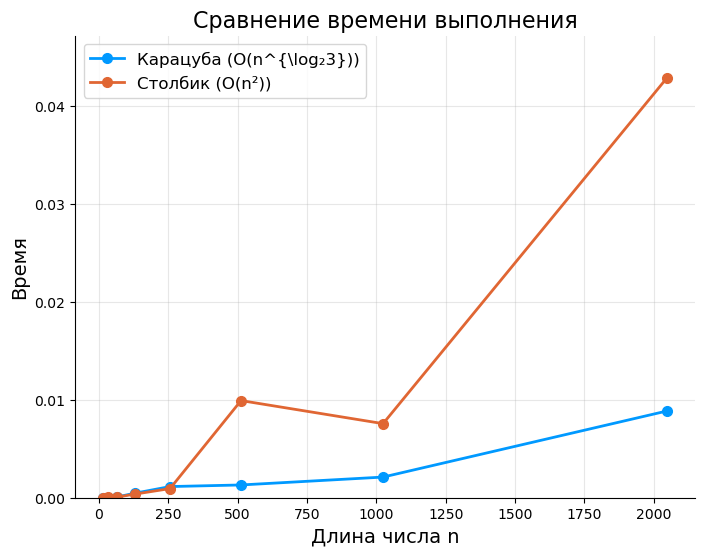

In [12]:
using PyPlot
using Random

function add_vec(a::Vector{Int}, b::Vector{Int})::Vector{Int}
    na = length(a)
    nb = length(b)
    n = max(na, nb)
    result = Vector{Int}(undef, n + 1)
    carry = 0
    i = 1
    while i <= na || i <= nb || carry > 0
        val_a = i <= na ? a[i] : 0
        val_b = i <= nb ? b[i] : 0
        sum_val = carry + val_a + val_b
        result[i] = sum_val & 1
        carry = sum_val >> 1
        i += 1
    end
    len = i - 1
    return len == 0 ? [0] : result[1:len]
end

function subtract_vec(a::Vector{Int}, b::Vector{Int})::Vector{Int}
    n = length(a)
    result = Vector{Int}(undef, n)
    borrow = 0
    for i in 1:n
        val_b = i <= length(b) ? b[i] : 0
        diff = a[i] - val_b - borrow
        if diff < 0
            diff += 2
            borrow = 1
        else
            borrow = 0
        end
        result[i] = diff
    end
    len = n
    while len > 1 && result[len] == 0
        len -= 1
    end
    return result[1:len]
end

function shift_left_vec(a::Vector{Int}, k::Int)::Vector{Int}
    if k == 0 || isempty(a) || all(a .== 0)
        return a
    end
    return [zeros(Int, k); a]
end

function split_vec(a::Vector{Int}, m::Int)::Tuple{Vector{Int}, Vector{Int}}
    n = length(a)
    if m >= n
        return ([0], a)
    end
    low = a[1:m]
    high = a[(m+1):end]
    
    len = length(high)
    while len > 1 && high[len] == 0
        len -= 1
    end
    return (high[1:len], low)
end

function generate_random_vec(n::Int)::Vector{Int}
    result = rand([0, 1], n)
    if all(result .== 0)
        result[1] = 1
    end
    return result
end

function mul_vec(x::Vector{Int}, y::Vector{Int})::Vector{Int}
    n = length(x)
    result = [0]
    for i in 1:n
        if x[i] == 1
            partial = shift_left_vec(y, i-1)
            result = add_vec(result, partial)
        end
    end
    return result
end

function karatsuba_mul_vec(x::Vector{Int}, y::Vector{Int})::Vector{Int}
    n = length(x)
    m = length(y)
    max_len = max(n, m)
    
    THRESHOLD = 32 
    
    if max_len <= THRESHOLD
        return mul_vec(x, y) 
    end

    k = div(max_len, 2)
    
    xh, xl = split_vec(x, k) 
    yh, yl = split_vec(y, k) 
    
    z0 = karatsuba_mul_vec(xl, yl) # z0 = xl * yl
    z2 = karatsuba_mul_vec(xh, yh) # z2 = xh * yh
    z1 = karatsuba_mul_vec(add_vec(xl, xh), add_vec(yl, yh)) # z1 = (xl+xh)*(yl+yh)

    # ad + bc = z1 - z2 - z0
    middle = subtract_vec(z1, z2)
    middle = subtract_vec(middle, z0)
    
    # Результат: z2 * 2^(2k) + middle * 2^k + z0
    term1 = shift_left_vec(z2, 2*k)
    term2 = shift_left_vec(middle, k)
    
    result = add_vec(term1, term2)
    result = add_vec(result, z0)
    
    return result
end


function bits_to_bigint(v::Vector{Int})::BigInt
    res = big(0)
    for i in reverse(eachindex(v)) # Итерируем с конца
        res <<= 1
        if v[i] == 1
            res += 1
        end
    end
    res = big(0)
    mul = big(1)
    for bit in v
        if bit == 1
            res += mul
        end
        mul <<= 1
    end
    return res
end

D = [16, 32, 64, 128, 256, 512, 1024, 2048] 

karatsuba_times = Float64[]
column_times = Float64[]

a_vec = nothing
b_vec = nothing

for bits in D
    local x = generate_random_vec(bits)
    local y = generate_random_vec(bits)

    if bits == 256
        global a_vec = x
        global b_vec = y
    end
    
    t_column = @elapsed mul_vec(x, y)
    
    t_karatsuba = @elapsed karatsuba_mul_vec(x, y)

    push!(column_times, t_column)
    push!(karatsuba_times, t_karatsuba)
end

println("-"^60)
println("Проверка корректности (n=256):")

res_school_vec   = mul_vec(a_vec, b_vec)
res_karatsuba_vec = karatsuba_mul_vec(a_vec, b_vec)

a_int = bits_to_bigint(a_vec)
b_int = bits_to_bigint(b_vec)
school_int    = bits_to_bigint(res_school_vec)
karatsuba_int = bits_to_bigint(res_karatsuba_vec)
native_result = a_int * b_int

println("a (BigInt)    = ", a_int)
println("b (BigInt)    = ", b_int)
println("a*b (Нативный)= ", native_result)
println("Столбик       = ", school_int)
println("Карацуба      = ", karatsuba_int)

println("\nСовпадает? ",
    school_int == native_result &&
    karatsuba_int == native_result
)
println("-"^60)

PyPlot.figure(figsize=(8, 6))
PyPlot.title("Сравнение времени выполнения", fontsize=16)
PyPlot.xlabel("Длина числа n", fontsize=14)
PyPlot.ylabel("Время", fontsize=14)

PyPlot.plot(D, karatsuba_times, marker="o", markersize=7, linewidth=2, color="#0099FF", label="Карацуба (O(n^{\\log₂3}))")
PyPlot.plot(D, column_times,    marker="o", markersize=7, linewidth=2, color="#E06633", label="Столбик (O(n²))")

PyPlot.grid(true, alpha=0.3)
PyPlot.legend(fontsize=12)

if maximum(column_times) > 0
    PyPlot.ylim(0, maximum(column_times) * 1.1)
end

ax = PyPlot.gca()
ax.spines["top"].set_visible(false)
ax.spines["right"].set_visible(false)

PyPlot.show()